In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")


In [ ]:
from dotenv import load_dotenv
import os
import pandas as pd
from pathlib import Path

# Load .env file
load_dotenv()

# Read paths
customers_path = os.getenv("CUSTOMERS_FILE")
orders_path = os.getenv("ORDERS_FILE")
web_path= os.getenv("WEB_FILE")
labels_path = os.getenv("LABELS_FILE")
interventions_path = os.getenv("INTERVENTIONS_FILE")
# Load .env file
load_dotenv()

# Read paths
customers_path = os.getenv("CUSTOMERS_FILE")
orders_path = os.getenv("ORDERS_FILE")
web_path = os.getenv("WEB_FILE")
labels_path = os.getenv("LABELS_FILE")
interventions_path = os.getenv("INTERVENTIONS_FILE")

# Fallback to local data folder when env vars are missing
base_path = Path("E:/data")

customers_path = customers_path or str(base_path / "customers.csv")
orders_path = orders_path or str(base_path / "support_tickets.csv")
web_path = web_path or str(base_path / "web_events_snapshot.csv")
labels_path = labels_path or str(base_path / "churn_labels.csv")
interventions_path = interventions_path or str(base_path / "intervention_history.csv")

customers = pd.read_csv(customers_path)
tickets = pd.read_csv(orders_path)
web = pd.read_csv(web_path)
labels = pd.read_csv(labels_path)
interventions = pd.read_csv(interventions_path)

datasets = {
    'customers': customers,
    'tickets': tickets,
    'web': web,
    'labels': labels,
    'interventions': interventions
}

for name, df in datasets.items():
    print('\n', '='*40)
    print(name.upper())
    print(df.info())
    print(df.describe(include='all'))
tickets = pd.read_csv(orders_path)
web = pd.read_csv(web_path)
labels = pd.read_csv(labels_path)
interventions = pd.read_csv(interventions_path)

datasets = {
    'customers': customers,
    'tickets': tickets,
    'web': web,
    'labels': labels,
    'interventions': interventions
}

for name, df in datasets.items():
    print('\n', '='*40)
    print(name.upper())
    print(df.info())
    print(df.describe(include='all'))
tickets = pd.read_csv(orders_path)
web = pd.read_csv(web_path)
labels = pd.read_csv(labels_path)
interventions = pd.read_csv(interventions_path)
datasets = {
    'customers': customers,
    'tickets': tickets,
    'web': web,
    'labels': labels,
    'interventions': interventions
}

for name, df in datasets.items():
    print('\n', '='*40)
    print(name.upper())
    print(df.info())
    print(df.describe(include='all'))


ValueError: Invalid file path or buffer object type: <class 'NoneType'>

In [4]:
# ==========================================
# DATA QUALITY REPORT GENERATION SCRIPT
# ==========================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

# ------------------------------------------
# FILE PATHS
# ------------------------------------------

base_path = Path("E:\data")

files = {
    "customers": "customers.csv",
    "support_tickets": "support_tickets.csv",
    "web_events": "web_events_snapshot.csv",
    "churn_labels": "churn_labels.csv",
    "intervention_history": "intervention_history.csv"
}

# ------------------------------------------
# LOAD DATASETS
# ------------------------------------------

datasets = {}

for name, file in files.items():
    datasets[name] = pd.read_csv(r"E:\data\customers.csv")

print("Datasets Loaded Successfully!")

# ------------------------------------------
# FUNCTION: CHECK OUTLIERS USING IQR
# ------------------------------------------

def detect_outliers_iqr(df, column):
    
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return len(outliers)

# ------------------------------------------
# GENERATE REPORT
# ------------------------------------------

report = []

report.append("# Data Quality Report\n")
report.append(f"Generated on: {datetime.now()}\n")

# ------------------------------------------
# DATASET LEVEL SUMMARY
# ------------------------------------------

summary_data = []

for name, df in datasets.items():

    summary_data.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })

summary_df = pd.DataFrame(summary_data)

report.append("## Dataset Summary\n")
#report.append(summary_df.to_markdown(index=False))
report.append("\n")

# ------------------------------------------
# DETAILED ANALYSIS
# ------------------------------------------

for name, df in datasets.items():

    report.append(f"## Dataset: {name}\n")

    # Basic Info
    report.append(f"- Shape: {df.shape}")
    report.append(f"- Duplicate Rows: {df.duplicated().sum()}")

    # Missing Values
    missing_values = df.isna().sum()
    missing_values = missing_values[missing_values > 0]

    if len(missing_values) > 0:

        report.append("\n### Missing Values")

        for col, val in missing_values.items():
            report.append(f"- {col}: {val}")

    else:
        report.append("\n- No Missing Values Found")

    # Data Types
    report.append("\n### Column Data Types")

    for col in df.columns:
        report.append(f"- {col}: {df[col].dtype}")

    # Invalid Values Check
    report.append("\n### Invalid Value Checks")

    for col in df.columns:

        if df[col].dtype == "object":

            empty_strings = (df[col].astype(str).str.strip() == "").sum()

            if empty_strings > 0:
                report.append(
                    f"- {col}: {empty_strings} empty string values"
                )

    # Outlier Detection
    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(numeric_cols) > 0:

        report.append("\n### Outlier Detection (IQR Method)")

        for col in numeric_cols:

            outlier_count = detect_outliers_iqr(df, col)

            report.append(
                f"- {col}: {outlier_count} potential outliers"
            )

    # Duplicate-like Records
    report.append("\n### Duplicate-like Records")

    duplicate_count = df.duplicated().sum()

    report.append(
        f"- Total duplicate rows found: {duplicate_count}"
    )

    report.append("\n---\n")

# ------------------------------------------
# JOIN ISSUES CHECK
# ------------------------------------------

report.append("## Join Issues Analysis\n")

# Example:
# Assuming customer_id is common across datasets

if "customer_id" in datasets["customers"].columns:

    customer_ids = set(datasets["customers"]["customer_id"])

    for name, df in datasets.items():

        if name != "customers" and "customer_id" in df.columns:

            other_ids = set(df["customer_id"])

            unmatched = other_ids - customer_ids

            report.append(
                f"- {name}: {len(unmatched)} customer_ids "
                f"not found in customers dataset"
            )

# ------------------------------------------
# SAVE REPORT
# ------------------------------------------

output_file = "data_quality_report.md"

with open(output_file, "w", encoding="utf-8") as f:
    f.write("\n".join(report))

print(f"\nData Quality Report Saved As: {output_file}")

# ------------------------------------------
# OPTIONAL: DISPLAY REPORT PREVIEW
# ------------------------------------------

print("\n".join(report[:50]))

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_7236\2445610139.py:14: SyntaxWarning: invalid escape sequence '\d'
  base_path = Path("E:\data")


Datasets Loaded Successfully!

Data Quality Report Saved As: data_quality_report.md
# Data Quality Report

Generated on: 2026-05-26 20:01:34.470274

## Dataset Summary



## Dataset: customers

- Shape: (2400, 9)
- Duplicate Rows: 0

### Missing Values
- loyalty_tier: 1386
- skin_type: 401

### Column Data Types
- customer_id: object
- signup_date: object
- city_tier: object
- age_group: object
- acquisition_channel: object
- loyalty_tier: object
- preferred_category: object
- skin_type: object
- marketing_consent: object

### Invalid Value Checks

### Duplicate-like Records
- Total duplicate rows found: 0

---

## Dataset: support_tickets

- Shape: (2400, 9)
- Duplicate Rows: 0

### Missing Values
- loyalty_tier: 1386
- skin_type: 401

### Column Data Types
- customer_id: object
- signup_date: object
- city_tier: object
- age_group: object
- acquisition_channel: object
- loyalty_tier: object
- preferred_category: object
- skin_type: object
- marketing_consent: object

### Invalid Valu

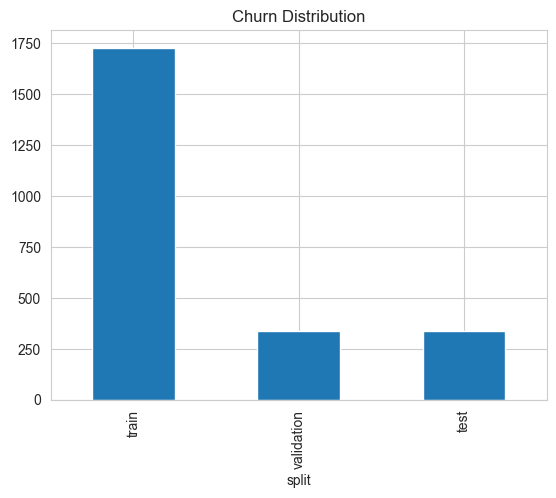

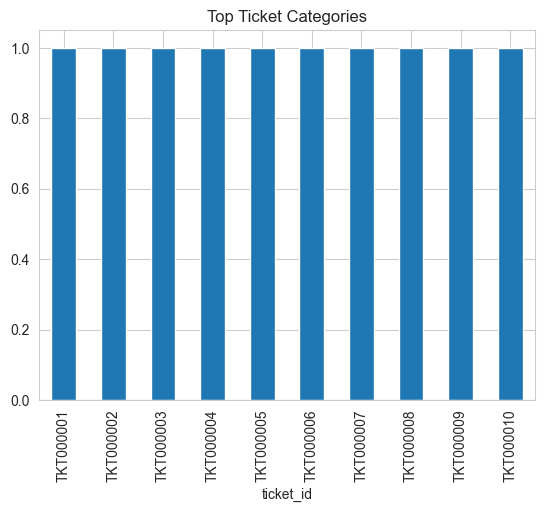

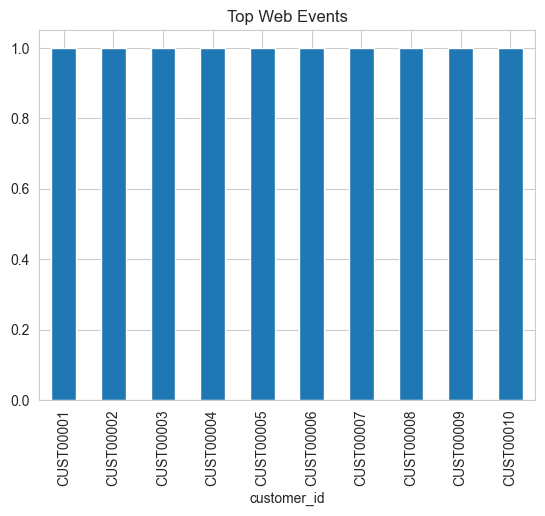

In [18]:
labels.iloc[:, -1].value_counts().plot(kind='bar', title='Churn Distribution')
plt.show()

tickets.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Ticket Categories')
plt.show()

web.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Web Events')
plt.show()